# Luma Customer Purchase Propensity Capstone

## Predicting purchase behavior and recommending customer engagement actions

**Author:** Ishaan Singh  
**Project type:** Classification, customer segmentation, and next best action decisioning

### Project purpose

In this capstone, I investigate whether customer behavior recorded across Luma web, mobile, and email touchpoints can predict a later purchase. I also use customer segmentation to translate those predictions into practical engagement actions.

The key design choice is an early journey observation window. I use only each customer's first five non-purchase interactions as features and predict whether that customer purchases later. This creates a more realistic marketing use case than allowing a model to see a completed purchase journey.

## 1. Business Understanding

Digital teams often send the same message to everyone because they do not know who is close to buying, who needs more information, and who is unlikely to respond. That approach can waste marketing spend and create irrelevant customer experiences.

I address this problem with three connected questions:

1. Can early customer behavior predict a later purchase?
2. Are there clear behavioral customer groups that can guide outreach?
3. What engagement action is appropriate for each predicted intent level?

I evaluate the classification models mainly with ROC-AUC because the dataset has more non-purchasers than purchasers and the business needs a useful ranking of customers by purchase likelihood. I also report precision, recall, F1, and average precision so that the quality of positive purchase predictions is visible.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Load and Inspect the Data

The repository contains a compressed copy of the supplied event-level CSV. Pandas reads the ZIP directly, which keeps the repository smaller while preserving a reproducible data source.

In [2]:
DATA_CANDIDATES = [
    Path("luma_post_extended.zip"),
    Path("data/luma_post_extended.zip"),
    Path("luma_post_extended.csv"),
    Path("data/luma_post_extended.csv"),
]

data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Place luma_post_extended.zip or luma_post_extended.csv in the repository root or data folder."
    )

compression = "zip" if data_path.suffix == ".zip" else None
raw = pd.read_csv(data_path, compression=compression, low_memory=False)

print(f"Loaded {data_path.name}: {raw.shape[0]:,} rows and {raw.shape[1]:,} columns")
raw.head(3)

Loaded luma_post_extended.zip: 46,110 rows and 95 columns


,Unnamed: 0,application.name,application.crashes.value,application.launches.value,application.firstLaunches.value,timestamp,_id,productListItems,commerce.productListViews.value,commerce.checkouts.value,commerce.purchases.value,commerce.productListAdds.value,commerce.order.currencyCode,commerce.order.purchaseID,commerce.productListOpens.value,commerce.productViews.value,receivedTimestamp,endUserIDs._experience.mcid.id,endUserIDs._experience.mcid.namespace.code,endUserIDs._experience.mcid.primary,endUserIDs._experience.aaid.id,endUserIDs._experience.aaid.namespace.code,endUserIDs._experience.aaid.primary,dataSource._id,web.webPageDetails.name,...,_experience.analytics.customDimensions.eVars.eVar19,_experience.analytics.customDimensions.eVars.eVar10,_experience.analytics.customDimensions.eVars.eVar15,_experience.analytics.customDimensions.eVars.eVar18,_experience.analytics.customDimensions.props.prop59,_experience.analytics.customDimensions.props.prop75,_experience.analytics.session.timestamp,_experience.analytics.session.num,_experience.analytics.session.web.webReferrer.type,_experience.analytics.session.web.webReferrer.URL,_experience.analytics.session.depth,_experience.analytics.session.search.isPaid,_experience.analytics.session.search.pageDepth,_experience.analytics.session.search.searchEngine,_experience.analytics.session.search.keywords,_experience.target.supplementalDataID,device.typeIDService,device.typeID,device.screenWidth,device.screenHeight,device.colorDepth,search.isPaid,search.searchEngine,search.keywords,search.pageDepth
0,0,NaN,NaN,NaN,NaN,2018-12-10 14:33:51,2E073CA785310000-4B4B2103C000397E,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,2018-12-10 14:33:51,79234187510694469448182042242884070212,ECID,True,F52B311DA66E07-645029D48D9E9C2,AAID,False,421228,luma: content: luma: us: en: experience: begin...,...,NaN,blog,NaN,NaN,NaN,2.9.0|3.3.0|Client Side ID|1.5.0|Unknown DIL v...,1544452431000,1,typed_bookmarked,NaN,1,False,0,NaN,NaN,NaN,https://ns.adobe.com/xdm/external/deviceatlas,205202.0,375.0,812.0,32.0,False,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,2018-12-10 14:12:23,2E073A2385308000-5865E302C00164A8,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,2018-12-10 14:12:23,87046886158001416452818236064317149037,ECID,True,1F2777B45164A32-6D0C2F26C6D70CA4,AAID,False,421228,luma: content: luma: us: en.html,...,87046886158001416452818236064317149037,home,NaN,NaN,NaN,2.9.0|3.3.0|Server Side ID|1.5.0|Unknown DIL v...,1544451143000,1,typed_bookmarked,NaN,1,False,0,NaN,NaN,NaN,NaN,NaN,3440.0,1440.0,24.0,False,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,2018-12-10 14:12:40,2E073A2C05308000-5F6B43092001D2D7,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,2018-12-10 14:12:40,87046886158001416452818236064317149037,ECID,True,1F2777B45164A32-6D0C2F26C6D70CA4,AAID,False,421228,luma: content: luma: us: en,...,87046886158001416452818236064317149037,home,NaN,NaN,pv,2.9.0|3.3.0|Existing ID|1.5.0|Unknown DIL vers...,1544451143000,1,typed_bookmarked,NaN,2,False,0,NaN,NaN,NaN,NaN,NaN,3440.0,1440.0,24.0,False,NaN,NaN,NaN


,rows,columns,duplicate_rows,columns_with_missing_values
0,46110,95,0,64


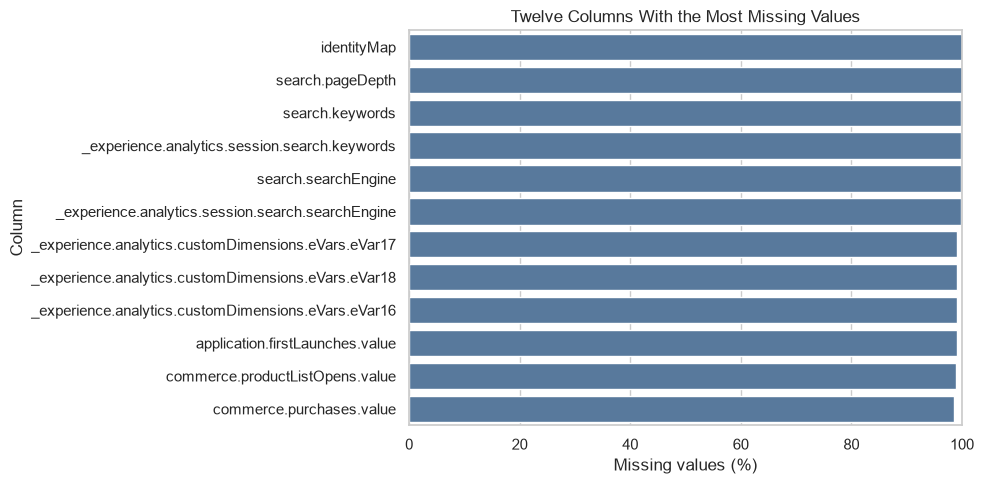

In [3]:
data_overview = pd.DataFrame(
    {
        "rows": [raw.shape[0]],
        "columns": [raw.shape[1]],
        "duplicate_rows": [raw.duplicated().sum()],
        "columns_with_missing_values": [raw.isna().any().sum()],
    }
)
display(data_overview)

missingness = (
    raw.isna().mean().sort_values(ascending=False).head(12).mul(100).rename("missing_percent")
)
plt.figure(figsize=(10, 5))
sns.barplot(x=missingness.values, y=missingness.index, color="#4C78A8")
plt.title("Twelve Columns With the Most Missing Values")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 3. Data Cleaning and Feature Engineering

I remove exact duplicate rows and rows without a customer identifier. Sparse event-counter fields are converted to numeric values and missing counters are treated as zero because a blank in these event fields means that event did not occur on that record.

For modeling, I exclude customers with fewer than five observed events because they do not have a complete early observation window. I also exclude the five customers who purchased inside the first five events. The target is therefore whether a customer purchased **after** the first five observed interactions.

In [4]:
customer_id_col = "endUserIDs._experience.mcid.id"
numeric_event_columns = [
    "commerce.productListViews.value",
    "commerce.checkouts.value",
    "commerce.purchases.value",
    "commerce.productListAdds.value",
    "commerce.productListOpens.value",
    "commerce.productViews.value",
    "web.webPageDetails.pageViews.value",
    "web.webInteraction.linkClicks.value",
    "application.launches.value",
]

events = raw.drop(columns=["Unnamed: 0"], errors="ignore").copy()
starting_rows = len(events)
events = events.drop_duplicates().dropna(subset=[customer_id_col]).copy()
events["customer_id"] = events[customer_id_col].astype(str)
events["event_time"] = pd.to_datetime(events["timestamp"], errors="coerce")
events = events.dropna(subset=["event_time"]).sort_values(["customer_id", "event_time"]).copy()

for column in numeric_event_columns:
    events[column] = pd.to_numeric(events[column], errors="coerce").fillna(0)

events["purchase_event"] = events["commerce.purchases.value"].gt(0).astype(int)
events["product_item_event"] = events["productListItems"].notna().astype(int)
events["email_touch"] = events["marketing.trackingCode"].notna().astype(int)
events["app_event"] = events["application.name"].notna().astype(int)
events["cart_page"] = (
    events["web.webPageDetails.siteSection"].fillna("").str.contains("cart", case=False, regex=False).astype(int)
)
events["checkout_page"] = (
    events["web.webPageDetails.siteSection"].fillna("").str.contains("checkout", case=False, regex=False).astype(int)
)
events["event_rank"] = events.groupby("customer_id").cumcount() + 1

first_purchase_rank = (
    events.loc[events["purchase_event"].eq(1)].groupby("customer_id")["event_rank"].min()
)
customer_event_counts = events.groupby("customer_id").size()

eligible_customers = customer_event_counts[customer_event_counts.ge(5)].index.difference(
    first_purchase_rank[first_purchase_rank.le(5)].index
)

target = pd.Series(0, index=eligible_customers, name="later_purchase", dtype=int)
eligible_purchasers = first_purchase_rank.index.intersection(eligible_customers)
target.loc[eligible_purchasers] = first_purchase_rank.loc[eligible_purchasers].gt(5).astype(int)

observation_events = events.loc[
    events["customer_id"].isin(eligible_customers) & events["event_rank"].le(5)
].copy()

cleaning_summary = pd.DataFrame(
    {
        "measure": [
            "Raw event records",
            "Usable cleaned event records",
            "Unique customers after cleaning",
            "Customers in five-event modeling cohort",
            "Later purchasers in modeling cohort",
        ],
        "value": [
            starting_rows,
            len(events),
            events["customer_id"].nunique(),
            len(eligible_customers),
            int(target.sum()),
        ],
    }
)
display(cleaning_summary)

,measure,value
0,Raw event records,46110
1,Usable cleaned event records,23054
2,Unique customers after cleaning,929
3,Customers in five-event modeling cohort,620
4,Later purchasers in modeling cohort,219


In [5]:
sum_features = [
    "commerce.productListViews.value",
    "commerce.productListAdds.value",
    "commerce.productListOpens.value",
    "commerce.productViews.value",
    "web.webPageDetails.pageViews.value",
    "web.webInteraction.linkClicks.value",
    "product_item_event",
    "email_touch",
    "app_event",
    "cart_page",
    "checkout_page",
]

customer_features = observation_events.groupby("customer_id")[sum_features].sum()
customer_features["unique_pages"] = observation_events.groupby("customer_id")["web.webPageDetails.name"].nunique()
customer_features["unique_sections"] = observation_events.groupby("customer_id")["web.webPageDetails.siteSection"].nunique()
customer_features["mean_session_depth"] = (
    pd.to_numeric(observation_events["_experience.analytics.session.depth"], errors="coerce")
    .groupby(observation_events["customer_id"])
    .mean()
)
customer_features["first_referrer"] = observation_events.groupby("customer_id")["web.webReferrer.type"].first()
customer_features["initial_section"] = observation_events.groupby("customer_id")["web.webPageDetails.siteSection"].first()
customer_features["country"] = observation_events.groupby("customer_id")["placeContext.geo.countryCode"].first()
customer_features["is_mobile_app"] = observation_events.groupby("customer_id")["application.name"].apply(
    lambda values: int(values.notna().any())
)

modeling_data = customer_features.join(target).reset_index()
for column in ["first_referrer", "initial_section", "country"]:
    modeling_data[column] = modeling_data[column].fillna("missing").astype(str)

print(f"Modeling cohort: {len(modeling_data):,} customers")
print(f"Later purchase rate: {modeling_data['later_purchase'].mean():.1%}")
modeling_data.head()

Modeling cohort: 620 customers
Later purchase rate: 35.3%


,customer_id,commerce.productListViews.value,commerce.productListAdds.value,commerce.productListOpens.value,commerce.productViews.value,web.webPageDetails.pageViews.value,web.webInteraction.linkClicks.value,product_item_event,email_touch,app_event,cart_page,checkout_page,unique_pages,unique_sections,mean_session_depth,first_referrer,initial_section,country,is_mobile_app,later_purchase
0,00160389637245032956395158514980391737,0.0,0.0,0.0,0.0,3.0,2.0,0,0,5,0,0,3,1,3.0,unknown,product section,US,1,0
1,00417082928223543447811670514593156961,0.0,0.0,0.0,0.0,3.0,2.0,0,0,5,0,0,3,0,3.0,unknown,missing,US,1,0
2,00419529275572216812832080788050428842,0.0,0.0,0.0,0.0,5.0,0.0,0,5,0,0,0,4,4,3.0,typed_bookmarked,home,US,0,0
3,00786876153896809918506707442781523262,0.0,0.0,0.0,0.0,3.0,2.0,1,0,5,0,0,3,2,3.0,unknown,product section,US,1,0
4,01110722127509229923233119888942631470,0.0,0.0,0.0,2.0,5.0,0.0,2,0,0,0,0,3,3,2.2,typed_bookmarked,gear: fitness,US,0,0


## 4. Exploratory Data Analysis

I first compare early customer behavior for people who later purchased and people who did not. These plots are descriptive, so they show association rather than proof that a behavior caused a purchase.

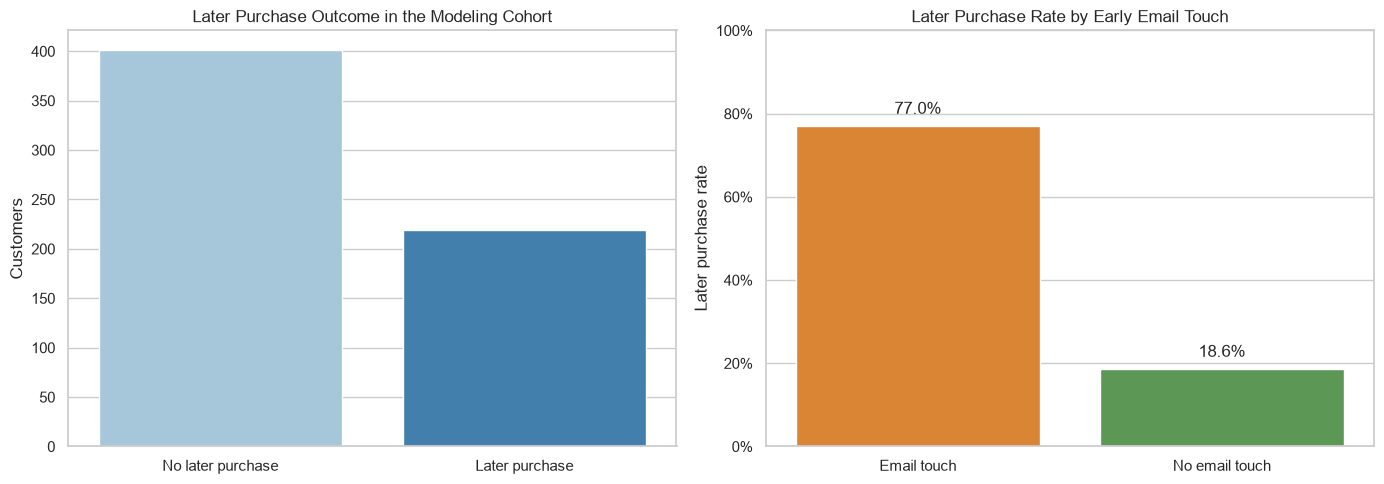

In [6]:
plot_data = modeling_data.copy()
plot_data["outcome"] = plot_data["later_purchase"].map({0: "No later purchase", 1: "Later purchase"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=plot_data, x="outcome", hue="outcome", legend=False, palette=["#9ECAE1", "#3182BD"], ax=axes[0])
axes[0].set_title("Later Purchase Outcome in the Modeling Cohort")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")

conversion_by_email = (
    plot_data.assign(email_seen=np.where(plot_data["email_touch"].gt(0), "Email touch", "No email touch"))
    .groupby("email_seen", as_index=False)["later_purchase"]
    .mean()
)
sns.barplot(data=conversion_by_email, x="email_seen", y="later_purchase", hue="email_seen", legend=False, palette=["#F58518", "#54A24B"], ax=axes[1])
axes[1].set_title("Later Purchase Rate by Early Email Touch")
axes[1].set_xlabel("")
axes[1].set_ylabel("Later purchase rate")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
for index, value in enumerate(conversion_by_email["later_purchase"]):
    axes[1].text(index, value + 0.03, f"{value:.1%}", ha="center")

plt.tight_layout()
plt.show()

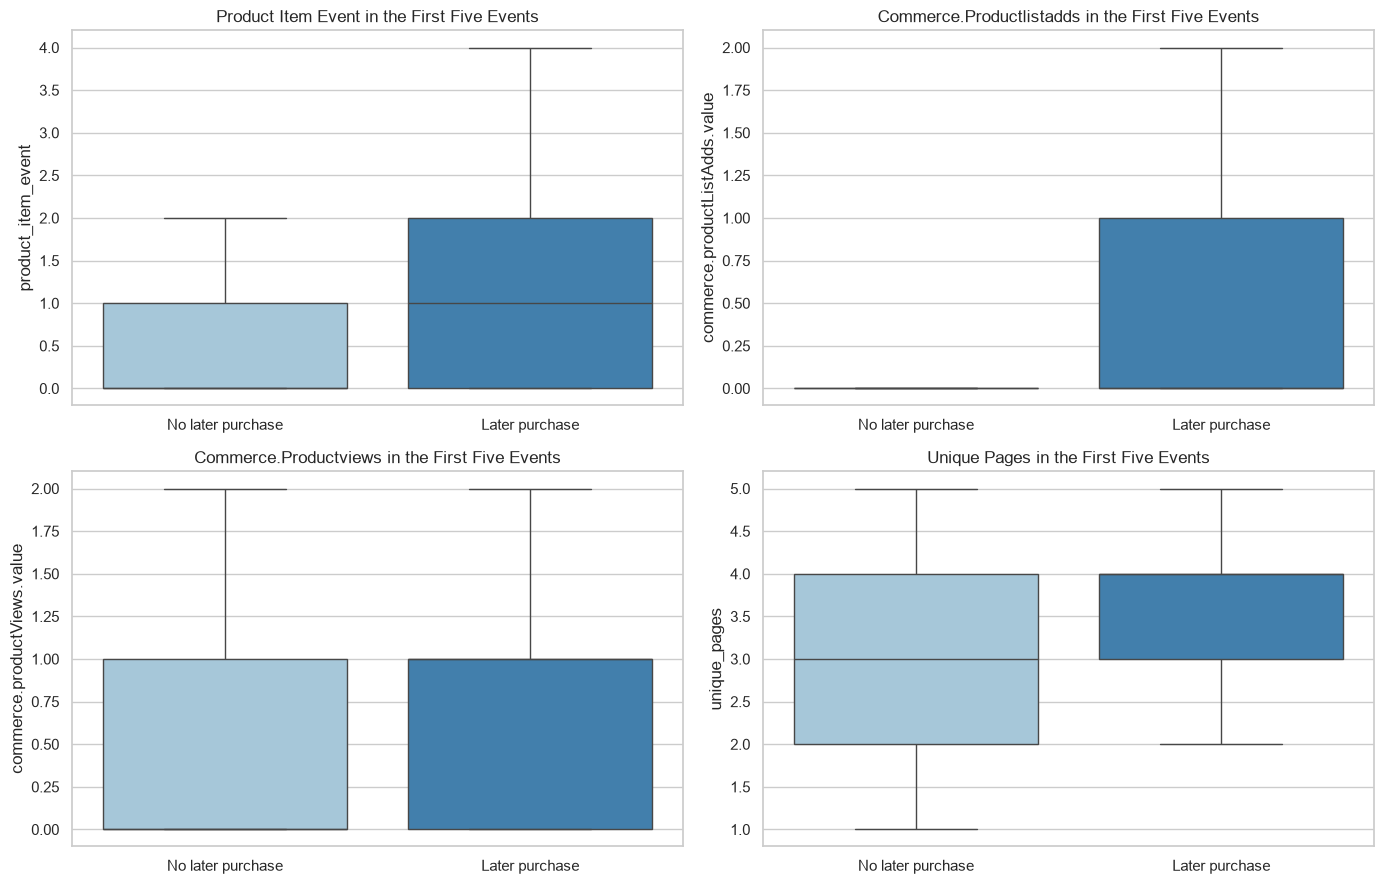

In [7]:
behavior_features = [
    "product_item_event",
    "commerce.productListAdds.value",
    "commerce.productViews.value",
    "unique_pages",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for feature, ax in zip(behavior_features, axes.ravel()):
    sns.boxplot(
        data=plot_data,
        x="outcome",
        y=feature,
        hue="outcome",
        legend=False,
        palette=["#9ECAE1", "#3182BD"],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(f"{feature.replace('_', ' ').replace('.value', '').title()} in the First Five Events")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

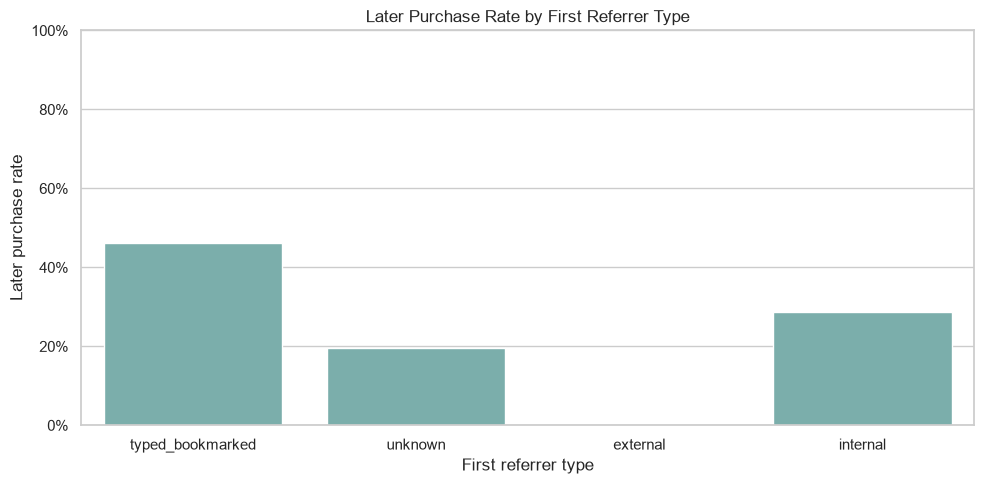

,first_referrer,customers,later_purchase_rate
0,typed_bookmarked,372,0.462
1,unknown,220,0.195
2,external,14,0.000
3,internal,14,0.286


In [8]:
referrer_summary = (
    modeling_data.groupby("first_referrer")
    .agg(customers=("customer_id", "size"), later_purchase_rate=("later_purchase", "mean"))
    .query("customers >= 10")
    .sort_values("customers", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=referrer_summary, x="first_referrer", y="later_purchase_rate", color="#72B7B2")
plt.title("Later Purchase Rate by First Referrer Type")
plt.xlabel("First referrer type")
plt.ylabel("Later purchase rate")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()

display(referrer_summary.round(3))

### Statistical evidence

I use two nonparametric tests because several behavior counts are highly skewed. The Mann-Whitney U test checks whether the distribution of an early behavior differs between later purchasers and non-purchasers. The chi-square test checks whether early email exposure and later purchase are associated. These tests support the descriptive patterns, but they do not establish causation.

In [9]:
non_purchasers = modeling_data.loc[modeling_data["later_purchase"].eq(0)]
later_purchasers = modeling_data.loc[modeling_data["later_purchase"].eq(1)]

test_rows = []
for feature in ["email_touch", "product_item_event", "commerce.productListAdds.value", "unique_pages"]:
    statistic, p_value = mannwhitneyu(
        non_purchasers[feature], later_purchasers[feature], alternative="two-sided"
    )
    test_rows.append(
        {
            "feature": feature,
            "median_no_later_purchase": non_purchasers[feature].median(),
            "median_later_purchase": later_purchasers[feature].median(),
            "p_value": p_value,
        }
    )

test_results = pd.DataFrame(test_rows)
email_table = pd.crosstab(modeling_data["email_touch"].gt(0), modeling_data["later_purchase"])
chi2, email_p_value, _, _ = chi2_contingency(email_table)

display(test_results.round(4))
print(f"Chi-square p-value for early email touch and later purchase: {email_p_value:.3g}")

,feature,median_no_later_purchase,median_later_purchase,p_value
0,email_touch,0.0,5.0,0.0
1,product_item_event,0.0,1.0,0.0
2,commerce.productListAdds.value,0.0,0.0,0.0
3,unique_pages,3.0,4.0,0.0


Chi-square p-value for early email touch and later purchase: 1.45e-42


## 5. Customer Segmentation

I use K-means clustering to group customers by their behavior in the five-event observation window. I evaluate two through five clusters with silhouette scores, then retain three clusters because it gives a clear and manageable set of engagement strategies.

In [10]:
cluster_features = [
    "commerce.productListAdds.value",
    "commerce.productViews.value",
    "product_item_event",
    "email_touch",
    "app_event",
    "cart_page",
    "unique_pages",
    "unique_sections",
]

cluster_scaled = StandardScaler().fit_transform(modeling_data[cluster_features])
silhouette_rows = []
for n_clusters in range(2, 6):
    labels = KMeans(n_clusters=n_clusters, n_init=20, random_state=RANDOM_STATE).fit_predict(cluster_scaled)
    silhouette_rows.append(
        {"clusters": n_clusters, "silhouette_score": silhouette_score(cluster_scaled, labels)}
    )

silhouette_results = pd.DataFrame(silhouette_rows)
display(silhouette_results.round(3))

kmeans = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
modeling_data["cluster"] = kmeans.fit_predict(cluster_scaled)

segment_names = {
    0: "Web explorers",
    1: "App focused browsers",
    2: "High intent shoppers",
}
modeling_data["segment"] = modeling_data["cluster"].map(segment_names)

segment_summary = (
    modeling_data.groupby("segment")
    .agg(
        customers=("customer_id", "size"),
        later_purchase_rate=("later_purchase", "mean"),
        mean_email_touches=("email_touch", "mean"),
        mean_product_items=("product_item_event", "mean"),
        mean_cart_adds=("commerce.productListAdds.value", "mean"),
        mean_app_events=("app_event", "mean"),
    )
    .sort_values("later_purchase_rate", ascending=False)
)
display(segment_summary.round(3))

,clusters,silhouette_score
0,2,0.391
1,3,0.434
2,4,0.469
3,5,0.499


,customers,later_purchase_rate,mean_email_touches,mean_product_items,mean_cart_adds,mean_app_events
segment,,,,,,
High intent shoppers,125,0.688,3.440,2.784,0.936,0.000
Web explorers,256,0.348,1.742,0.742,0.004,0.000
App focused browsers,239,0.184,0.021,0.159,0.004,4.603


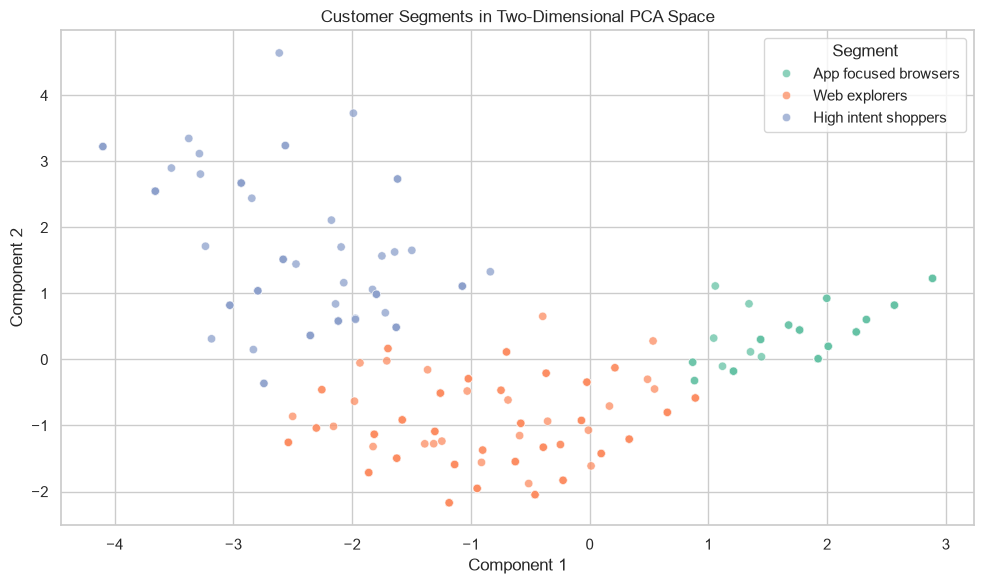

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coordinates = pca.fit_transform(cluster_scaled)
cluster_plot = pd.DataFrame(
    {"Component 1": coordinates[:, 0], "Component 2": coordinates[:, 1], "Segment": modeling_data["segment"]}
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_plot, x="Component 1", y="Component 2", hue="Segment", palette="Set2", alpha=0.75)
plt.title("Customer Segments in Two-Dimensional PCA Space")
plt.tight_layout()
plt.show()

## 6. Predictive Modeling

I compare a dummy classifier, logistic regression, and random forest. The dummy model provides a no-skill reference point. Logistic regression is a transparent benchmark. Random forest can represent nonlinear relationships between early behaviors and later purchase.

I use stratified five-fold cross-validation so each validation fold has a similar share of purchasers. The final test set is held out until after model selection.

In [12]:
X = modeling_data.drop(columns=["customer_id", "later_purchase", "cluster", "segment"])
y = modeling_data["later_purchase"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

models = {
    "Dummy baseline": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision", "f1": "f1"}

cv_rows = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append(
        {
            "model": model_name,
            "mean_roc_auc": scores["test_roc_auc"].mean(),
            "std_roc_auc": scores["test_roc_auc"].std(),
            "mean_average_precision": scores["test_average_precision"].mean(),
            "mean_f1": scores["test_f1"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("mean_roc_auc", ascending=False)
display(cv_results.round(3))

,model,mean_roc_auc,std_roc_auc,mean_average_precision,mean_f1
2,Random forest,0.841,0.032,0.755,0.703
1,Logistic regression,0.833,0.022,0.745,0.691
0,Dummy baseline,0.500,0.000,0.353,0.000


### Hyperparameter tuning

I tune the random forest with grid search on the training portion only. The search optimizes cross-validated ROC-AUC and tests the number of trees, maximum tree depth, and minimum observations required in a leaf.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)

parameter_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 8],
    "model__min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best training cross-validated ROC-AUC: {grid_search.best_score_:.3f}")

Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
Best training cross-validated ROC-AUC: 0.839


,metric,value
0,ROC-AUC,0.819
1,Average precision,0.714
2,Accuracy,0.794
3,Precision,0.689
4,Recall,0.764
5,F1,0.724


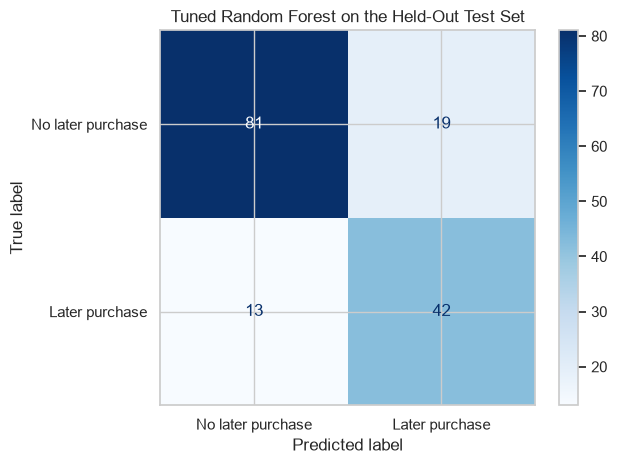

                   precision    recall  f1-score   support

No later purchase       0.86      0.81      0.84       100
   Later purchase       0.69      0.76      0.72        55

         accuracy                           0.79       155
        macro avg       0.78      0.79      0.78       155
     weighted avg       0.80      0.79      0.80       155



In [14]:
best_model = grid_search.best_estimator_
test_probability = best_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.50).astype(int)

test_results = pd.DataFrame(
    {
        "metric": ["ROC-AUC", "Average precision", "Accuracy", "Precision", "Recall", "F1"],
        "value": [
            roc_auc_score(y_test, test_probability),
            average_precision_score(y_test, test_probability),
            accuracy_score(y_test, test_prediction),
            precision_score(y_test, test_prediction),
            recall_score(y_test, test_prediction),
            f1_score(y_test, test_prediction),
        ],
    }
)
display(test_results.round(3))

ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, display_labels=["No later purchase", "Later purchase"], cmap="Blues")
plt.title("Tuned Random Forest on the Held-Out Test Set")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_prediction, target_names=["No later purchase", "Later purchase"]))

### Model interpretation

I use permutation importance on the held-out test data. It measures how much the model's ROC-AUC decreases when one input feature is randomly shuffled. Larger positive values identify features that helped the model rank customers by later purchase likelihood.

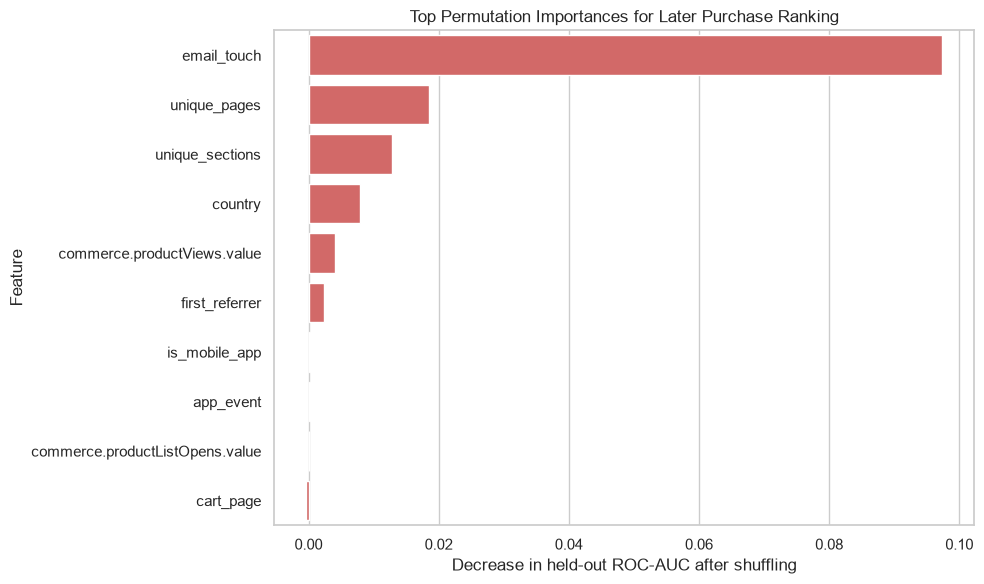

,feature,importance_mean,importance_std
7,email_touch,0.097,0.019
11,unique_pages,0.018,0.012
12,unique_sections,0.013,0.010
16,country,0.008,0.013
3,commerce.productViews.value,0.004,0.004
14,first_referrer,0.002,0.005
17,is_mobile_app,0.000,0.003
8,app_event,0.000,0.003
2,commerce.productListOpens.value,0.000,0.000
9,cart_page,-0.000,0.001


In [15]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_results = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_results, x="importance_mean", y="feature", color="#E45756")
plt.title("Top Permutation Importances for Later Purchase Ranking")
plt.xlabel("Decrease in held-out ROC-AUC after shuffling")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance_results.round(3))

## 7. Next Best Action Prototype

The final step converts model probabilities and observed behavior into a simple decision table. This is a prototype for marketing operations, not an automated policy. Any real deployment should test these actions with controlled experiments and respect customer communication preferences.

In [16]:
full_feature_matrix = modeling_data.drop(columns=["customer_id", "later_purchase", "cluster", "segment"])
modeling_data["purchase_probability"] = best_model.predict_proba(full_feature_matrix)[:, 1]

def next_best_action(row):
    if row["purchase_probability"] >= 0.70 and row["commerce.productListAdds.value"] > 0:
        return "Cart reminder with saved items"
    if row["purchase_probability"] >= 0.70:
        return "Personalized product recommendation"
    if row["purchase_probability"] >= 0.35 and row["email_touch"] == 0:
        return "Opt-in email or content nurture"
    if row["purchase_probability"] >= 0.35:
        return "Product education and comparison content"
    return "Low-frequency awareness content"

modeling_data["next_best_action"] = modeling_data.apply(next_best_action, axis=1)

action_summary = (
    modeling_data.groupby("next_best_action")
    .agg(
        customers=("customer_id", "size"),
        mean_predicted_probability=("purchase_probability", "mean"),
        observed_later_purchase_rate=("later_purchase", "mean"),
    )
    .sort_values("mean_predicted_probability", ascending=False)
)
display(action_summary.round(3))

,customers,mean_predicted_probability,observed_later_purchase_rate
next_best_action,,,
Cart reminder with saved items,96,0.871,0.854
Personalized product recommendation,52,0.783,0.904
Product education and comparison content,47,0.635,0.511
Opt-in email or content nurture,111,0.499,0.396
Low-frequency awareness content,314,0.196,0.070


## 8. Findings, Recommendations, and Limitations

### Findings

1. Early behavior has meaningful predictive value. Both logistic regression and random forest materially outperform the no-skill baseline in cross-validation.
2. Early email exposure, product interaction, cart adds, and browsing breadth are strongly associated with later purchase in this dataset.
3. The high intent shopper segment has the greatest observed later purchase rate and is appropriate for timely, personalized outreach.
4. The model identifies useful associations, not causal effects. An email touch may reflect that marketing already targeted a customer who was likely to purchase.

### Recommendations

1. Prioritize cart reminder and product recommendation tests for customers with high predicted purchase probability.
2. Use useful product education for medium probability customers, especially those without an observed email touch.
3. Keep outreach low frequency for low probability customers and monitor opt-out or disengagement behavior.
4. Validate the proposed actions with an A/B test before rollout. Measure incremental conversion, revenue, and customer experience outcomes.

### Limitations and next steps

This is an observational dataset, so the analysis cannot prove that a touchpoint caused a purchase. The customer sample is also modest, and the outcome is limited to purchase occurrence rather than customer value. I reduced target leakage by using only the first five events and excluding early purchasers, but a production system should use a clearly defined time horizon such as purchase within seven days after a scored session.

Next, I would add a time-based train and test split, test calibrated probabilities and decision thresholds, incorporate campaign costs and customer lifetime value, and evaluate recommendations through randomized experiments.